# Imports & Setup

In [1]:
# =========================
# Imports & Setup
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_plot(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", bbox_inches="tight", dpi=300)

# Load Clean Data

In [2]:
# =========================
# Load Data
# =========================
df = pd.read_csv("../data/processed/cleaned_delivery_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (45082, 25)


,order_id,driver_id,driver_age,driver_rating,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,...,vehicle_type,num_deliveries,is_festival,city,delivery_time_min,distance_km,order_hour,order_day,is_weekend,is_peak_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,...,motorcycle,0,No,Urban,24,3.025149,11.0,Saturday,1,0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,...,scooter,1,No,Metropolitian,33,20.183530,19.0,Friday,0,1
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,1900-01-01 08:30:00,...,motorcycle,1,No,Urban,26,1.552758,8.0,Saturday,1,0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,1900-01-01 18:00:00,...,motorcycle,1,No,Metropolitian,21,7.790401,18.0,Tuesday,0,1
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,1900-01-01 13:30:00,...,scooter,1,No,Metropolitian,30,6.210138,13.0,Saturday,1,1


# Define Target & Features

In [3]:
# =========================
# Define Target & Features
# =========================
target = "delivery_time_min"

X = df.drop(columns=[target])
y = df[target]

# Encode Categorical Variables

In [6]:
# =========================
# Encode Categorical Variables
# =========================
X_encoded = X.copy()

for col in X_encoded.select_dtypes(include=["object", "category", "string"]).columns:
    X_encoded[col] = X_encoded[col].astype("category").cat.codes

print("Encoded shape:", X_encoded.shape)

Encoded shape: (45082, 24)


# Correlation Analysis (Filter Method)

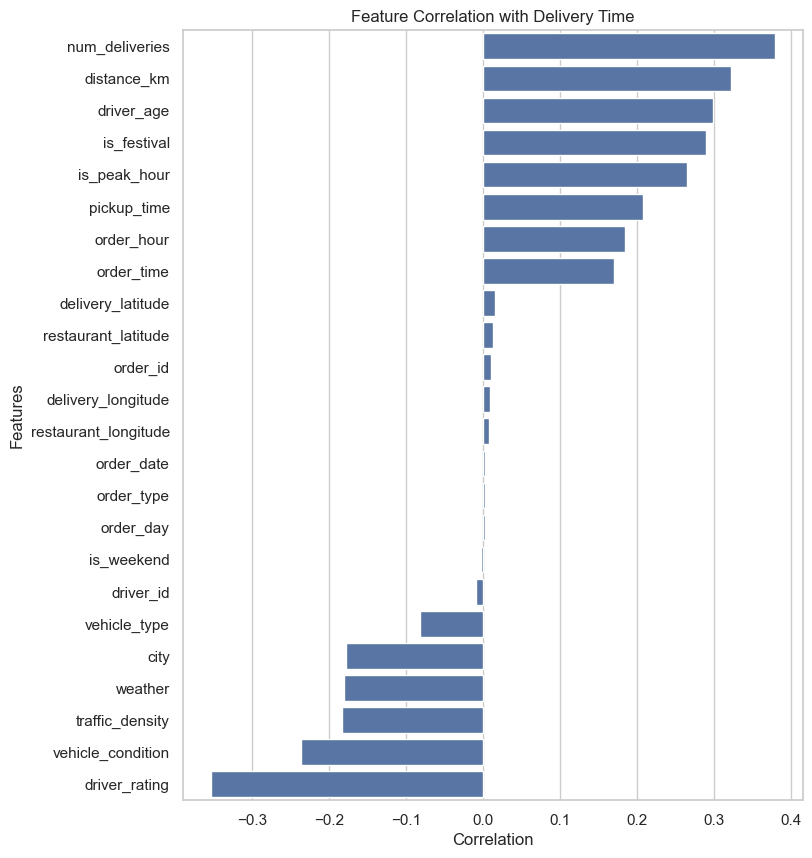

num_deliveries          0.378756
distance_km             0.321902
driver_age              0.298267
is_festival             0.289265
is_peak_hour            0.264454
pickup_time             0.207413
order_hour              0.184618
order_time              0.170284
delivery_latitude       0.014923
restaurant_latitude     0.013317
order_id                0.010471
delivery_longitude      0.008220
restaurant_longitude    0.007663
order_date              0.002558
order_type              0.002404
order_day               0.002269
is_weekend             -0.003111
driver_id              -0.009869
vehicle_type           -0.081947
city                   -0.177659
weather                -0.181465
traffic_density        -0.182891
vehicle_condition      -0.237148
driver_rating          -0.353364
Name: delivery_time_min, dtype: float64


In [7]:
# =========================
# Correlation with Target
# =========================
corr_df = X_encoded.copy()
corr_df[target] = y

corr_matrix = corr_df.corr()

target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 10))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Feature Correlation with Delivery Time")
plt.xlabel("Correlation")
plt.ylabel("Features")
save_plot("feature_correlation_with_target")
plt.show()

print(target_corr)

# Mutual Information (Non-linear Importance)

In [ ]:
# =========================
# Handle Missing Values BEFORE MI
# =========================
X_encoded = X_encoded.fillna(X_encoded.median(numeric_only=True))



# OR???//
# for col in X_encoded.columns:
#     if X_encoded[col].dtype in ["int64", "float64"]:
#         X_encoded[col] = X_encoded[col].fillna(X_encoded[col].median())
#     else:
#         X_encoded[col] = X_encoded[col].fillna(0)

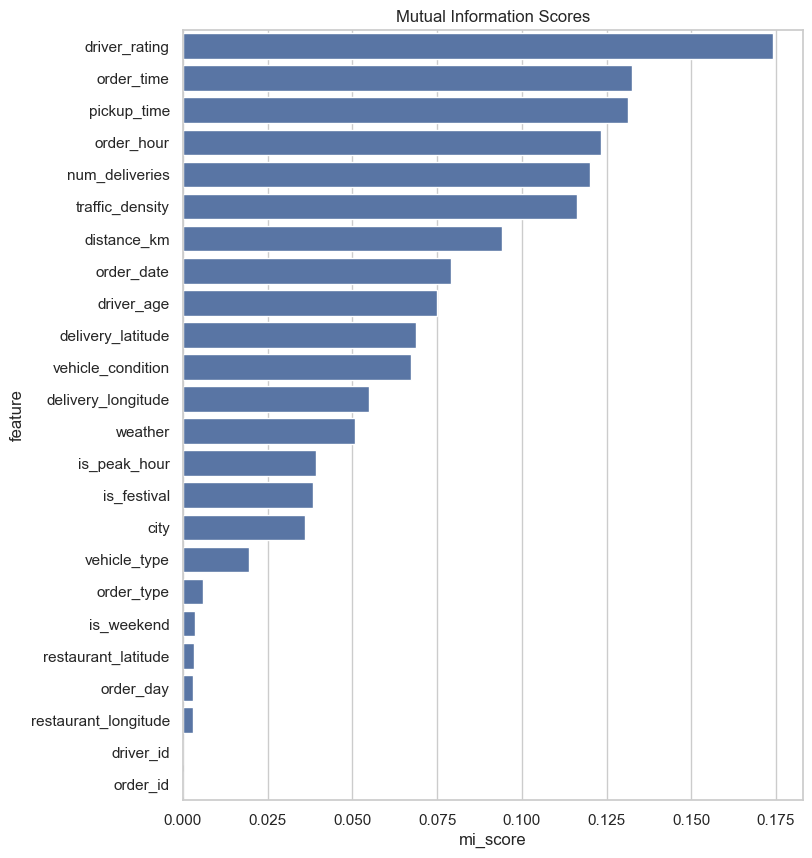

                 feature  mi_score
3          driver_rating  0.174276
9             order_time  0.132507
10           pickup_time  0.131353
20            order_hour  0.123316
16        num_deliveries  0.120107
12       traffic_density  0.116151
19           distance_km  0.094279
8             order_date  0.079166
2             driver_age  0.075055
6      delivery_latitude  0.068913
13     vehicle_condition  0.067212
7     delivery_longitude  0.054924
11               weather  0.050695
23          is_peak_hour  0.039134
17           is_festival  0.038242
18                  city  0.036085
15          vehicle_type  0.019364
14            order_type  0.005943
22            is_weekend  0.003451
4    restaurant_latitude  0.003267
21             order_day  0.003081
5   restaurant_longitude  0.002824
1              driver_id  0.000000
0               order_id  0.000000


In [10]:
# =========================
# Mutual Information
# =========================
mi_scores = mutual_info_regression(X_encoded, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "mi_score": mi_scores
}).sort_values(by="mi_score", ascending=False)

# Plot
plt.figure(figsize=(8, 10))
sns.barplot(data=mi_df, x="mi_score", y="feature")
plt.title("Mutual Information Scores")
save_plot("mutual_information_scores")
plt.show()

print(mi_df)

# Random Forest Feature Importance (Embedded Method)

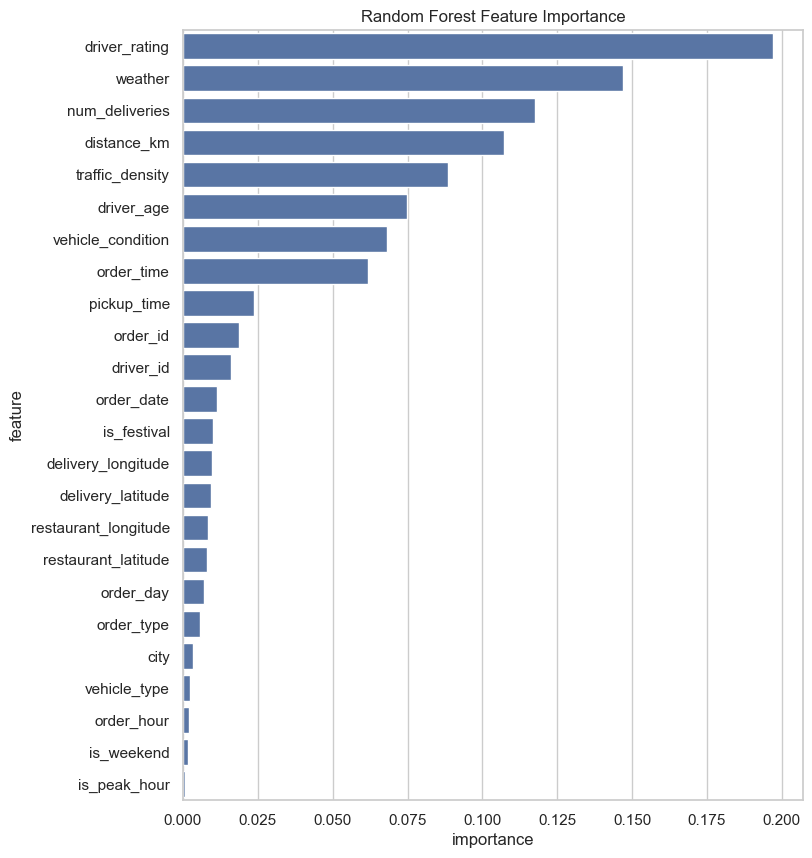

                 feature  importance
3          driver_rating    0.197261
11               weather    0.146874
16        num_deliveries    0.117631
19           distance_km    0.107341
12       traffic_density    0.088423
2             driver_age    0.074670
13     vehicle_condition    0.068140
9             order_time    0.061714
10           pickup_time    0.023641
0               order_id    0.018728
1              driver_id    0.016115
8             order_date    0.011285
17           is_festival    0.010076
7     delivery_longitude    0.009724
6      delivery_latitude    0.009432
5   restaurant_longitude    0.008497
4    restaurant_latitude    0.008172
21             order_day    0.006983
14            order_type    0.005598
18                  city    0.003266
15          vehicle_type    0.002306
20            order_hour    0.001882
22            is_weekend    0.001617
23          is_peak_hour    0.000623


In [11]:
# =========================
# Random Forest Importance
# =========================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_encoded, y)

rf_importance = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(8, 10))
sns.barplot(data=rf_importance, x="importance", y="feature")
plt.title("Random Forest Feature Importance")
save_plot("rf_feature_importance")
plt.show()

print(rf_importance)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_encoded, y)

xgb_importance = pd.DataFrame({
    "feature": X_encoded.columns,
    "xgb_importance": xgb.feature_importances_
})

In [ ]:
feature_scores = feature_scores.merge(
    xgb_importance, on="feature", how="left"
)

In [ ]:
feature_scores["xgb_importance"] = (
    feature_scores["xgb_importance"] - feature_scores["xgb_importance"].min()
) / (
    feature_scores["xgb_importance"].max() - feature_scores["xgb_importance"].min()
)

feature_scores["final_score"] = feature_scores[
    ["correlation", "mutual_info", "rf_importance", "xgb_importance"]
].mean(axis=1)

# Combine All Importance Scores

In [12]:
# =========================
# Combine Scores
# =========================
feature_scores = pd.DataFrame({
    "feature": X_encoded.columns,
    "correlation": target_corr.reindex(X_encoded.columns).values,
    "mutual_info": mi_df.set_index("feature").reindex(X_encoded.columns)["mi_score"].values,
    "rf_importance": rf_importance.set_index("feature").reindex(X_encoded.columns)["importance"].values
})

feature_scores = feature_scores.fillna(0)

# Normalize scores
for col in ["correlation", "mutual_info", "rf_importance"]:
    feature_scores[col] = (feature_scores[col] - feature_scores[col].min()) / (
        feature_scores[col].max() - feature_scores[col].min()
    )

# Final score
feature_scores["final_score"] = feature_scores[
    ["correlation", "mutual_info", "rf_importance"]
].mean(axis=1)

feature_scores = feature_scores.sort_values(by="final_score", ascending=False)

print(feature_scores)

                 feature  correlation  mutual_info  rf_importance  final_score
16        num_deliveries     1.000000     0.689179       0.595045     0.761408
19           distance_km     0.922343     0.540974       0.542716     0.668678
3          driver_rating     0.000000     1.000000       1.000000     0.666667
9             order_time     0.715248     0.760332       0.310680     0.595420
2             driver_age     0.890060     0.430667       0.376564     0.565764
10           pickup_time     0.765963     0.753706       0.117060     0.545576
20            order_hour     0.734827     0.707590       0.006404     0.482941
12       traffic_density     0.232849     0.666477       0.446505     0.448610
11               weather     0.234795     0.290892       0.743757     0.423148
17           is_festival     0.877764     0.219432       0.048073     0.381757
23          is_peak_hour     0.843875     0.224550       0.000000     0.356142
8             order_date     0.486153     0.454256  

# Select Top Features

In [14]:
# =========================
# Feature Selection
# =========================
# TOP_N = 11  # you can tune this

# selected_features = feature_scores.head(TOP_N)["feature"].tolist()

# print("Selected Features:")
# print(selected_features)


### ORRRR
selected_features = feature_scores[
    feature_scores["final_score"] > 0.2
]["feature"].tolist()

Selected Features:
['num_deliveries', 'distance_km', 'driver_rating', 'order_time', 'driver_age', 'pickup_time', 'order_hour', 'traffic_density', 'weather', 'is_festival', 'is_peak_hour']


# Multicollinearity Check

In [15]:
# =========================
# Remove Highly Correlated Features
# =========================
corr_matrix = X_encoded[selected_features].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop:", to_drop)

final_features = [f for f in selected_features if f not in to_drop]

print("Final Selected Features:")
print(final_features)

Highly correlated features to drop: []
Final Selected Features:
['num_deliveries', 'distance_km', 'driver_rating', 'order_time', 'driver_age', 'pickup_time', 'order_hour', 'traffic_density', 'weather', 'is_festival', 'is_peak_hour']


# Save Selected Features

In [16]:
# =========================
# Save Features
# =========================
with open("../models/selected_features.pkl", "wb") as f:
    pickle.dump(final_features, f)

print("Feature list saved successfully!")

Feature list saved successfully!


In [ ]:
feature_scores.to_csv("../reports/feature_scores.csv", index=False)

# Key Insights

In [17]:
# =========================
# Insights Summary
# =========================

print("Top Influential Features:")
print(feature_scores.head(10)[["feature", "final_score"]])

Top Influential Features:
            feature  final_score
16   num_deliveries     0.761408
19      distance_km     0.668678
3     driver_rating     0.666667
9        order_time     0.595420
2        driver_age     0.565764
10      pickup_time     0.545576
20       order_hour     0.482941
12  traffic_density     0.448610
11          weather     0.423148
17      is_festival     0.381757


In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_scores.head(15),
    x="final_score",
    y="feature"
)

plt.title("Final Combined Feature Importance")
save_plot("final_feature_importance")
plt.show()